# Semi-Supervised Dual-Head Solution of the Kitaev-Chain Spectral Problem

## I. Introduction

The Kitaev chain is the minimal model in which a topological superconducting
phase transition and its Majorana bound states can be studied exactly. This
notebook trains a physics-informed neural network to represent the lowest
non-negative Bogoliubov--de Gennes (BdG) eigenpair as a continuous function
of the chemical potential $\mu$, across the transition at $|\mu| = 2t$.

It is the label-anchored counterpart of the chiral-basis notebook. Where
that treatment removes exact data entirely by transferring the problem to
the Majorana basis, the present one keeps a small set of eigenpairs obtained
from `numpy.linalg.eigh` and relies on the physics residual to generalise
away from them. The network has two heads, one for the energy $E(\mu)$ and
one for the eigenvector $\psi(\mu)$, and three constraints -- unit norm of
$\psi$, non-negativity of $E$, and the input scaling of the SIREN backbone
-- are built into the architecture rather than left to the loss. What
remains is a four-term loss (two data terms, two physics terms) with a
single physics-weight annealing schedule.

The optimiser schedule, the collocation domain $-4t < \mu < 4t$, and the
evaluation probe are the same as in the chiral notebook, so the two models
are compared on identical metrics.

## II. Formalism

### A. Bogoliubov--de Gennes Hamiltonian and its symmetries

In the Nambu basis
$\Psi = (c_1,\dots,c_N,c_1^\dagger,\dots,c_N^\dagger)^{\mathsf T}$ the BdG
Hamiltonian of the open Kitaev chain is a real symmetric $2N \times 2N$
matrix, linear in $\mu$,

$$
H(\mu) \;=\; H_{\mathrm{base}} \;+\; \mu\, H_{\mu\text{-diag}}
\;=\;
\begin{pmatrix} A(\mu) & B \\[2pt] B^{\mathsf T} & -A(\mu) \end{pmatrix},
\tag{1}
$$

with $A(\mu)$ carrying the on-site potential and the hopping and $B$ the
$p$-wave pairing. The representation makes one symmetry manifest,
particle--hole conjugation $\Xi\,H(\mu)\,\Xi = -H(\mu)$ with
$\Xi = \tau_x \otimes \mathbb{1}_N$. In a residual formulation this symmetry
carries no independent information: since $\Xi H \Xi = -H$ holds identically,
the penalty $\lVert H(\Xi\psi) + E(\Xi\psi) \rVert^2$ equals
$\lVert H\psi - E\psi \rVert^2$ term by term, so the particle--hole loss
below is numerically equal to the Schr\"odinger residual at every step.

### B. Spectral target and the topological transition

The learning target is the lowest non-negative eigenvalue $E(\mu)$ of
$H(\mu)$ and its eigenvector $\psi(\mu)$, partitioned into particle and hole
blocks $\psi = (u, w)$. Throughout the topological phase $|\mu| < 2t$ this
eigenvalue is a near-zero mode whose eigenvector is exponentially localised
at the two ends of the chain -- the Majorana signature -- while in the
trivial phase $|\mu| > 2t$ it rises as $E \to |\mu| - 2t$ and the
eigenvector delocalises through the bulk.

Deep in the topological phase the pair $\pm\lambda_1$ is degenerate to below
floating-point precision, and `numpy.linalg.eigh` returns an arbitrary
rotation within the corresponding two-dimensional near-zero eigenspace. The
overlap of a prediction with a single such vector is therefore ill-defined,
and eigenvector accuracy is instead measured as the norm of the projection
onto that two-dimensional span (Sec. VII C and Fig. 2).

### C. Exact labels and gauge fixing

`SupervisedKitaevDataset` produces the labelled triples $(\mu, E, \psi)$ by
diagonalising $H(\mu)$ directly. Each label costs one diagonalisation, so
the labelled set is kept small. An eigenvector returned by `eigh` is defined
only up to an overall sign; the dataset sorts the sampled $\mu$ in ascending
order and flips each eigenvector so that
$\langle \psi(\mu_k), \psi(\mu_{k-1}) \rangle > 0$, giving labels that vary
smoothly with $\mu$. A single global sign per connected component of the
sampled domain remains, and is resolved during training by the
sign-aligned data term of Sec. IV.

## III. Network architecture

The surrogate is a sinusoidal representation network (SIREN) with a shared
backbone and two linear heads,

$$
\mu \;\longmapsto\; \big( E(\mu),\; \psi(\mu) \big)
\;\in\; \mathbb{R}_{\ge 0} \times \mathbb{R}^{2N}.
\tag{2}
$$

Sinusoidal activations are used because the physics residual differentiates
the network output with respect to $\mu$, and a sine and all of its
derivatives remain bounded and smooth. Three properties are enforced within
the forward evaluation and are therefore absent from the loss.

First, the eigenvector head is normalised to unit Euclidean length,
$\psi \to \psi / \lVert \psi \rVert$; this fixes the amplitude but not the
sign. Second, the energy head is passed through a softplus,
$E = \operatorname{softplus}(\text{raw}, \beta = 10)$, so that $E \ge 0$ by
construction. Softplus rather than ReLU because the entire topological phase
has a true target of exactly zero, and ReLU's gradient vanishes for every
negative pre-activation, which would starve the model of signal precisely
where it needs it. Third, the input is divided by `input_scale` before the
first SIREN layer; the standard SIREN initialisation assumes unit-scale
inputs, so `input_scale` is set to $4.0$ to match the training domain
$-4t < \mu < 4t$. The frequency `hidden_omega_0` and the depth
`hidden_layers` are the two axes reserved for the accompanying ablation.

## IV. Loss functional

`SemiSupervisedLoss` combines a small labelled batch with a large label-free
batch, concatenated so that the labelled rows come first, and minimises

$$
\mathcal{L} \;=\;
\mathcal{L}_E \;+\; \mathcal{L}_\psi
\;+\; w_{\mathrm{phys}}(\text{epoch}) \,
\big( \mathcal{L}_{\mathrm{res}} + \mathcal{L}_{\mathrm{PH}} \big).
\tag{3}
$$

$\mathcal{L}_E$ and $\mathcal{L}_\psi$ are mean-squared errors against the
exact labels, evaluated on the labelled rows only. $\mathcal{L}_\psi$ aligns
the sign of each label to the corresponding prediction before the
comparison: an eigenvector's sign is arbitrary, and nothing else in the loss
breaks that ambiguity, since $\mathcal{L}_{\mathrm{res}}$ and
$\mathcal{L}_{\mathrm{PH}}$ are both invariant under $\psi \to -\psi$.
Without the alignment a correctly learned eigenstate on the "wrong" sign
would score a large spurious error, which was a real training instability at
the transition during this notebook's development.

$\mathcal{L}_{\mathrm{res}} = \big\langle \lVert H(\mu)\psi - E\psi \rVert^2
\big\rangle$ is the Schr\"odinger residual, requiring no ground truth.
$\mathcal{L}_{\mathrm{PH}}$ is the same residual re-evaluated on $\Xi\psi$ at
energy $-E$; by the identity of Sec. II A it is numerically equal to
$\mathcal{L}_{\mathrm{res}}$ at every step and is retained only to match the
formulation this project's earlier notebooks converged on.

$w_{\mathrm{phys}}$ anneals from $0.01$ to $1.0$ over the first
`anneal_duration` epochs -- the mirror image of the pinned-FSM schedule on
the unsupervised side. Early in training $E$ and $\psi$ are close to random,
so the residual terms, which are computed from those predictions rather than
from ground truth, are an unreliable signal until the model has locked onto
the labelled data. The ramp completes within the AdamW phase, and
`run_two_phase` continues the epoch count into the L-BFGS phase, so
$w_{\mathrm{phys}}$ stays at $1.0$ there rather than restarting.

Unlike the chiral loss, which has two terms and no schedule because its
structural guarantees remove the data-versus-physics tension entirely, here
that tension is genuine and the schedule is what manages it.

## V. Label and collocation sampling

`MuSampler` draws from a mixture of weighted `SamplingRegion` intervals.
Weights are relative -- a region's share of a batch is its own weight over
the total -- so adding a region changes only that region's share and leaves
every other region's absolute sample count untouched. `SEMI_SUPERVISED_REGIONS`
places a thin uniform slice over the full domain $[-4t, 4t]$, a
heavily-weighted band over the topological interior $(-1.8t, 1.8t)$, a narrow
window on either side of each transition, and the trivial phase out to
$\pm 4t$.

The labelled set is $630$ training and $126$ validation triples, both
multiples of the regions' total weight so every region contributes a whole
number of samples; the label-free pool is $4096$ $\mu$-only points. Two
further single-batch frozen pools, one labelled and one label-free, are
built for the L-BFGS stage, which requires a stationary objective.

## VI. Implementation

### A. Imports

The model, loss, sampling, training, and evaluation components used below
are provided by the `kitaev` package.

In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np
import torch
from accelerate import Accelerator
from sesh import Session

from kitaev.analytical import KitaevChainHamiltonian
from kitaev.data import SupervisedKitaevDataset, UnsupervisedMuGenerator
from kitaev.data.mu_sampler import MuSampler
from kitaev.data.sampling_region import SamplingRegion
from kitaev.models import SirenPINNDualHead
from kitaev.training import BdGEvaluationProbe, TwoPhaseConfig, run_two_phase
from kitaev.training.config import TrainerConfig
from kitaev.training.loss import SemiSupervisedLoss
from kitaev.training.trainer import _build_kitaev_operators
from kitaev.visualisation import sweep_wavefunctions

### B. Session and device

A `Session` collects the run's log file and figure outputs; the
`Accelerator` selects the compute device.

In [2]:
session = Session(
    name="dual-head-semi-supervised",
    output_root=Path("../../results/logs"),
    enable_mlflow=False,
)

accelerator = Accelerator()
session.info(f"Using device: {accelerator.device}")

2026-08-27 22:23:18 | INFO | dual-head-semi-supervised | Experiment session: dual-head-semi-supervised initialised.
2026-08-27 22:23:18 | INFO | dual-head-semi-supervised | Seeding engine completed using base reference: 42
2026-08-27 22:23:18 | INFO | dual-head-semi-supervised | Local workflow runtime tracking directed to: ../../results/logs/20260827_222318_dual-head-semi-supervised
2026-08-27 22:23:18 | INFO | dual-head-semi-supervised | Using device: mps


### C. Hamiltonian

`_build_kitaev_operators` assembles the batched
$(H_{\mathrm{base}},\, H_{\mu\text{-diag}},\, \Xi)$ triple in the same
operator convention as `KitaevChainHamiltonian.build`. Unlike the chiral
loss, `SemiSupervisedLoss` consumes these operators directly to form
$H(\mu)$ for its residual terms. All quantities are in units of $t$, with
$N = 20$ and $\Delta = 0.5\,t$, so the transition lies at $\mu = 2t$.

In [3]:
N = 20
t = 1.0
delta = 0.5
session.info(f"N = {N}, t = {t}, delta = {delta}, transition at |mu| = {2 * t}")

hamiltonian = KitaevChainHamiltonian(n_sites=N, hopping=t, pairing=delta)

H_base, H_mu_diag, Xi = _build_kitaev_operators(N, hopping=t, pairing=delta)
H_base = H_base.to(accelerator.device)
H_mu_diag = H_mu_diag.to(accelerator.device)
Xi = Xi.to(accelerator.device)

2026-08-27 22:23:18 | INFO | dual-head-semi-supervised | N = 20, t = 1.0, delta = 0.5, transition at |mu| = 2.0


### D. Label and collocation sampling

The region mixture of Sec. V. The weights are relative and sum to $7$, so
the labelled sample counts below are chosen as multiples of $7$ and every
region contributes a whole number of points.

In [4]:
torch.manual_seed(42)

# Weights are relative (need not sum to 1.0): each region's share is its own
# weight divided by the total, so adding a region changes only that region's
# share -- every other region's absolute sample count is untouched.
SEMI_SUPERVISED_REGIONS = (
    SamplingRegion(low=-4.0, high=4.0, weight=1.0),  # thin full-domain slice
    SamplingRegion(low=-1.8, high=1.8, weight=3.0),  # topological interior
    SamplingRegion(low=-2.2, high=-1.8, weight=1.0),  # left transition window
    SamplingRegion(low=1.8, high=2.2, weight=1.0),  # right transition window
    SamplingRegion(low=-4.0, high=-2.0, weight=0.5),  # left trivial phase
    SamplingRegion(low=2.0, high=4.0, weight=0.5),  # right trivial phase
)  # weights sum to 7; the sample counts below are multiples of 7

### E. Datasets

$630$ labelled triples are diagonalised exactly for training and $126$ for
validation; the label-free stream is a pre-generated pool of $4096$ $\mu$
values with no diagonalisation. `train_loader` and `val_loader` yield
$(\mu, E, \psi)$ batches, `unlabeled_loader` yields $(\mu,)$ batches only,
and `UnifiedTrainer.fit` tells them apart by batch length alone.

The L-BFGS stage optimises a stationary objective, so it is given its own
single-batch pools: the whole labelled set as one $630$-row batch, and a
frozen $2048$-point label-free batch. Passing these as `lbfgs_train_loader`
and `lbfgs_unlabeled_loader` freezes both contributions to the residual for
the second stage.

In [5]:
train_dataset = SupervisedKitaevDataset(
    sampler=MuSampler(SEMI_SUPERVISED_REGIONS),
    total_samples=630,
    hamiltonian=hamiltonian,
)
train_loader = train_dataset.dataloader(batch_size=64, shuffle=True)

val_dataset = SupervisedKitaevDataset(
    sampler=MuSampler(SEMI_SUPERVISED_REGIONS),
    total_samples=126,
    hamiltonian=hamiltonian,
)
val_loader = val_dataset.dataloader(batch_size=126, shuffle=False)

unlabeled_loader = UnsupervisedMuGenerator(
    sampler=MuSampler(SEMI_SUPERVISED_REGIONS)
).dataloader(total_samples=4096, batch_size=128)

# Frozen single-batch pools for the L-BFGS stage: the labelled contribution
# and the label-free contribution must both be the same batch every epoch,
# or the quasi-Newton curvature estimate is built on a moving target.
lbfgs_labeled_loader = train_dataset.dataloader(
    batch_size=len(train_dataset), shuffle=False
)
lbfgs_unlabeled_loader = UnsupervisedMuGenerator(
    sampler=MuSampler(SEMI_SUPERVISED_REGIONS)
).dataloader(total_samples=2048, batch_size=2048)

session.info(
    f"{len(train_dataset)} labelled training samples, "
    f"{len(val_dataset)} labelled validation samples, "
    "4096 label-free AdamW samples, 2048 frozen L-BFGS samples"
)

2026-08-27 22:23:19 | INFO | dual-head-semi-supervised | 630 labelled training samples, 126 labelled validation samples, 4096 label-free AdamW samples, 2048 frozen L-BFGS samples


### F. Network, loss, optimisation schedule, and error probe

The configuration below is the baseline the accompanying ablation varies one
axis at a time from -- not a set of independent knobs. It is the point this
notebook converged on after diagnosing, in order, an insufficient label
count, a missing annealing schedule, a sign-ambiguity instability, an
under-resourced transition region, and an unnormalised input domain;
`input_scale` is raised here from the model default to $4.0$ for the
widened $[-4t, 4t]$ domain. `hidden_omega_0` and `hidden_layers` are the
two ablation axes.

Training proceeds in two stages, orchestrated by `run_two_phase`. AdamW
under a cosine learning-rate decay carries the parameters into a
well-conditioned basin while $w_{\mathrm{phys}}$ completes its ramp; L-BFGS
under a strong-Wolfe line search, on the frozen pools of Sec. VI E, then
drives the residual down further by exploiting curvature information. The
runner continues the epoch count into the second stage, so
$w_{\mathrm{phys}}$ stays at $1.0$ rather than restarting.

`BdGEvaluationProbe` evaluates the model against exact diagonalisation on a
fixed $\mu$ grid every `every` epochs and records the energy, edge-weight,
and eigenvector-subspace errors into the run history. The dual-head model
already returns $(E, \psi)$, so no adapter is needed; the same probe on the
same grid scores the chiral and Nambu models, so the three are directly
comparable.

In [6]:
# SirenPINNDualHead's `n_sites` argument is the *output* dimension of the
# psi head, i.e. the full BdG dimension 2N, not the physical site count N.
# input_scale = 4.0 matches the [-4t, 4t] training domain; hidden_omega_0
# (2.0) and energy_softplus_beta (10.0) are the model defaults.
model = SirenPINNDualHead(
    n_sites=hamiltonian.dim,
    hidden_features=64,
    hidden_layers=3,
    input_scale=4.0,
)

# physics_weight ramps 0.01 -> 1.0 over the first anneal_duration epochs,
# completing inside the AdamW phase so the model locks onto the exact labels
# before the physics residual reaches full strength.
loss_fn = SemiSupervisedLoss(total_epochs=3000, anneal_duration=1000)

# Stage 1: AdamW + cosine decay.  Stage 2: L-BFGS + strong-Wolfe line search
# on the frozen pools.  history_size ~ 20 is ample for a network this size.
TWO_PHASE = TwoPhaseConfig(
    adam_epochs=3000,
    adam_lr=8e-4,
    adam_weight_decay=1e-6,
    lbfgs_epochs=100,
    lbfgs_max_iter=20,
    lbfgs_history_size=20,
    lbfgs_line_search_fn="strong_wolfe",
)

# Shared trainer settings; run_two_phase overrides `epochs` per stage and
# disables gradient clipping for the L-BFGS stage.  Early stopping is off so
# each stage runs its full budget and the comparison is clean.
two_phase_base = TrainerConfig(
    epochs=1, print_freq=300, patience=None, grad_clip_norm=1.0
)

# Physical-error probe over the full domain.  adapt=None: the dual head
# returns (E, psi) directly.
probe = BdGEvaluationProbe(
    n_sites=N,
    hopping=t,
    pairing=delta,
    mu_grid=np.linspace(-4.0, 4.0, 240),
    every=50,
    session=session,
)

### G. Training

The loss (3) is minimised in two stages on a single network: $3000$ epochs
of AdamW under a cosine decay on the labelled and label-free batches, then
$100$ epochs of L-BFGS under a strong-Wolfe line search on the frozen pools.
`run_two_phase` returns the trained model and both stages' histories
concatenated; this combined history drives every figure of Sec. VII.

This is a full experimental run: on a single GPU or Apple-silicon device the
AdamW stage takes a few minutes and the L-BFGS stage a little longer per
epoch. Reduce `TWO_PHASE.adam_epochs` and `TWO_PHASE.lbfgs_epochs` for a
quick pass.

In [7]:
trained_model, history = run_two_phase(
    session=session,
    accelerator=accelerator,
    model=model,
    loss_fn=loss_fn,
    train_loader=train_loader,
    H_base=H_base,
    H_mu_diag=H_mu_diag,
    Xi=Xi,
    two_phase=TWO_PHASE,
    base_config=two_phase_base,
    callbacks=[probe],  # error probe (AdamW stage)
    val_loader=val_loader,
    unlabeled_loader=unlabeled_loader,
    lbfgs_train_loader=lbfgs_labeled_loader,  # frozen labelled batch (L-BFGS)
    lbfgs_unlabeled_loader=lbfgs_unlabeled_loader,  # frozen label-free batch
    lbfgs_callbacks=[probe],  # keep the probe across both stages
)

adam_epochs = TWO_PHASE.adam_epochs
session.info(
    f"two-phase run complete: {len(history['train_loss'])} epochs recorded "
    f"({adam_epochs} AdamW + {TWO_PHASE.lbfgs_epochs} L-BFGS)"
)
session.info(
    f"train loss   AdamW end: {history['train_loss'][adam_epochs - 1]:.4e}  "
    f"-> L-BFGS end: {history['train_loss'][-1]:.4e}"
)
session.info(
    f"val psi MSE  AdamW end: {history['val_psi'][adam_epochs - 1]:.4e}  "
    f"-> L-BFGS end: {history['val_psi'][-1]:.4e}"
)
session.info(
    f"E MAE        first probe: {history['probe_e_mae'][0]:.4e}  "
    f"-> last probe: {history['probe_e_mae'][-1]:.4e}"
)

2026-08-27 22:23:19 | INFO | dual-head-semi-supervised | --- Two-phase: AdamW warm-up ---
2026-08-27 22:23:19 | INFO | dual-head-semi-supervised | --- Starting training (SemiSupervisedLoss) ---
2026-08-27 22:23:19 | INFO | dual-head-semi-supervised | probe | step     1 | E MAE 1.882e-01 (topo 3.380e-02, triv 3.426e-01) | edge MAE 3.549e-01 | infidelity 6.991e-01 (max 9.792e-01)
2026-08-27 22:23:22 | INFO | dual-head-semi-supervised | probe | step    50 | E MAE 1.025e-02 (topo 1.439e-03, triv 1.907e-02) | edge MAE 1.194e-02 | infidelity 1.034e-02 (max 2.132e-01)
2026-08-27 22:23:25 | INFO | dual-head-semi-supervised | probe | step   100 | E MAE 8.288e-03 (topo 1.226e-03, triv 1.535e-02) | edge MAE 1.366e-02 | infidelity 1.312e-02 (max 8.271e-01)
2026-08-27 22:23:28 | INFO | dual-head-semi-supervised | probe | step   150 | E MAE 6.825e-03 (topo 1.767e-03, triv 1.188e-02) | edge MAE 9.873e-03 | infidelity 9.040e-03 (max 4.989e-01)
2026-08-27 22:23:30 | INFO | dual-head-semi-supervised | p

## VII. Results

The trained dual-head model is evaluated directly, in its native
two-output form: the softplus energy $E(\mu) \ge 0$ and the unit-norm
$2N$-component eigenvector, which is anchored to the gauge-fixed labels of
Sec. II C through $\mathcal{L}_\psi$. All comparisons below are against
exact diagonalisation of $H(\mu)$ on a uniform grid over $[-4t, 4t]$.

### Figure style

A common style is applied to the figures of this section: the topological
region $|\mu| < 2t$ is shaded and both transitions at $\mu = \pm 2t$ are
marked.

In [13]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

INK = "#1b2a41"
CORAL = "#e4572e"
TEAL = "#2a9d8f"
SLATE = "#8d99ae"
GOLD = "#e9c46a"

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": SLATE,
        "axes.linewidth": 0.8,
        "axes.grid": True,
        "grid.color": "#e6e8ec",
        "grid.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 13,
        "axes.titleweight": "600",
        "axes.titlepad": 12,
        "axes.labelsize": 11,
        "axes.labelcolor": INK,
        "text.color": INK,
        "xtick.color": SLATE,
        "ytick.color": SLATE,
        "font.family": "sans-serif",
        "legend.frameon": False,
        "legend.fontsize": 10,
    }
)


def _mark_topological(ax, t, mu_max):
    """Shade the topological phase |mu| < 2t and mark both transitions."""
    ax.axvspan(-2 * t, 2 * t, color=TEAL, alpha=0.07, lw=0)
    for x in (-2 * t, 2 * t):
        ax.axvline(x, color=SLATE, ls=(0, (4, 3)), lw=1.1)
    ax.set_xlim(-mu_max, mu_max)
    ax.xaxis.set_major_locator(MultipleLocator(1.0))


def _annotate_phases(ax, t, y):
    ax.text(
        0.0,
        y,
        "topological",
        ha="center",
        va="center",
        fontsize=9,
        color=TEAL,
        weight="600",
    )
    for x in (-3 * t, 3 * t):
        ax.text(
            x,
            y,
            "trivial",
            ha="center",
            va="center",
            fontsize=9,
            color=SLATE,
            weight="600",
        )

### A. Optimisation history and physical error

Figure 1 shows the total loss and its four components on a logarithmic
scale, with the physics weight $w_{\mathrm{phys}}$ on the right axis and the
AdamW $\to$ L-BFGS hand-over marked. The data terms $\mathcal{L}_E$ and
$\mathcal{L}_\psi$ fall as the model fits the labels; $\mathcal{L}_{\mathrm{res}}$
and $\mathcal{L}_{\mathrm{PH}}$ coincide, as anticipated in Sec. II A, and
fall once $w_{\mathrm{phys}}$ has ramped in. The L-BFGS phase is visible as a
further step down.

Figure 2 plots the quantities recorded by `BdGEvaluationProbe` against the
cumulative epoch index: the energy mean absolute error, split into the
topological and trivial phases, the combined edge-weight error, and the
eigenvector subspace infidelity $1 - \lVert P\,\psi_{\mathrm{pred}} \rVert$.
Once the data terms have converged, the total loss in Fig. 1 changes little,
but the probe errors keep falling; the probe is resolved in the physically
meaningful quantities and is the better guide to whether the model is still
improving, exactly as in the chiral notebook.

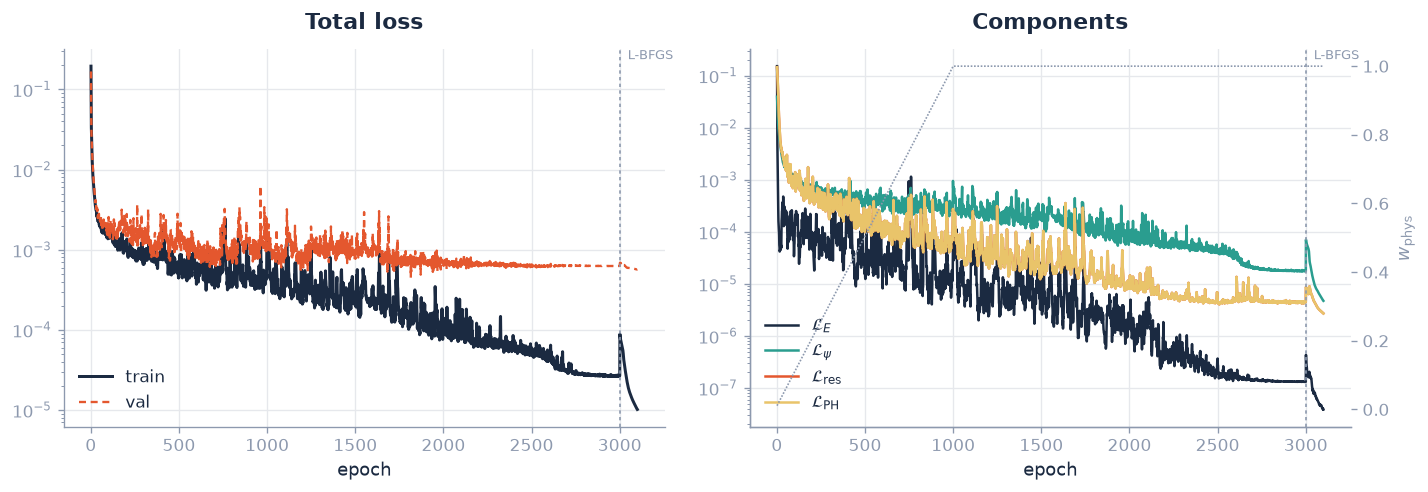

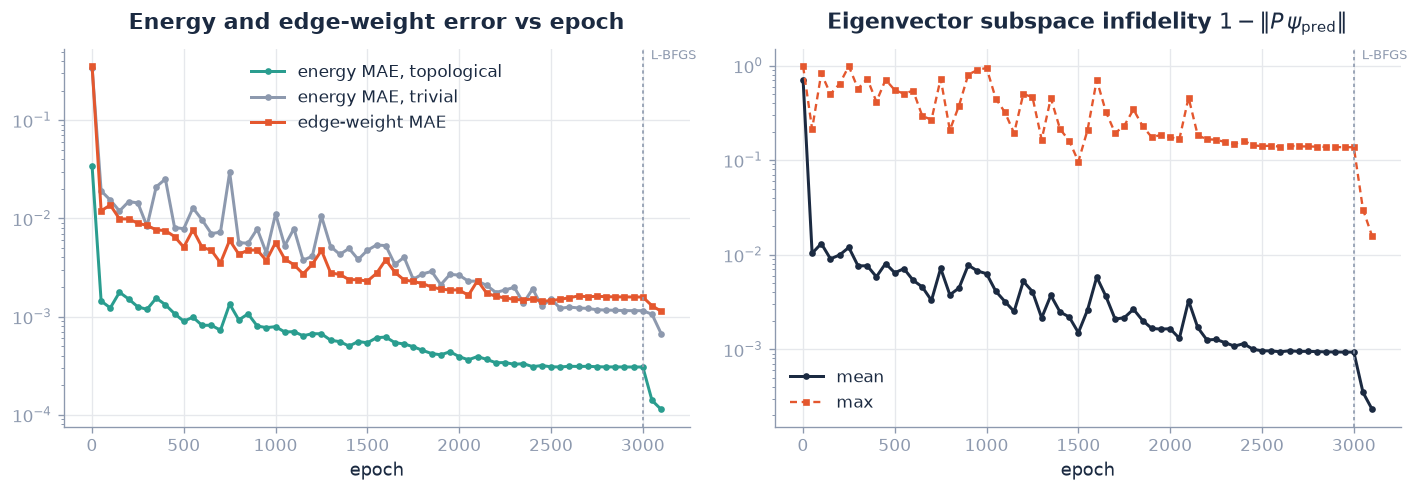

In [14]:
epochs = range(1, len(history["train_loss"]) + 1)
split = TWO_PHASE.adam_epochs  # AdamW -> L-BFGS hand-over


def _mark_phase_split(ax, top=True):
    ax.axvline(split, color=SLATE, ls=(0, (2, 2)), lw=1.0)
    ax.text(
        split,
        ax.get_ylim()[1] if top else ax.get_ylim()[0],
        "  L-BFGS",
        ha="left",
        va="top" if top else "bottom",
        fontsize=8,
        color=SLATE,
    )


# --- Figure 1: loss history and components -----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(epochs, history["train_loss"], color=INK, lw=1.8, label="train")
if "val_loss" in history:
    axes[0].plot(
        epochs, history["val_loss"], color=CORAL, lw=1.4, ls=(0, (3, 2)), label="val"
    )
axes[0].set_yscale("log")
axes[0].set_title("Total loss")
axes[0].set_xlabel("epoch")
_mark_phase_split(axes[0])
axes[0].legend()

for key, colour, label in (
    ("train_e", INK, r"$\mathcal{L}_E$"),
    ("train_psi", TEAL, r"$\mathcal{L}_\psi$"),
    ("train_res", CORAL, r"$\mathcal{L}_{\rm res}$"),
    ("train_ph", GOLD, r"$\mathcal{L}_{\rm PH}$"),
):
    axes[1].plot(epochs, history[key], color=colour, lw=1.5, label=label)
axes[1].set_yscale("log")
axes[1].set_title("Components")
axes[1].set_xlabel("epoch")
_mark_phase_split(axes[1])
axes[1].legend(loc="lower left")

wt = axes[1].twinx()
wt.plot(epochs, history["train_physics_wt"], color=SLATE, lw=1.0, ls=(0, (1, 1)))
wt.set_ylabel(r"$w_{\rm phys}$", color=SLATE)
wt.set_ylim(-0.05, 1.05)
wt.tick_params(axis="y", colors=SLATE)
wt.grid(False)

fig.tight_layout()
fig.savefig(session.path() / "loss_history.png", bbox_inches="tight")

# --- Figure 2: physical errors recorded by the probe ------------------------
p_epoch = np.asarray(history["probe_epoch"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(
    p_epoch,
    history["probe_e_mae_topological"],
    color=TEAL,
    lw=1.8,
    marker="o",
    ms=3,
    label="energy MAE, topological",
)
axes[0].plot(
    p_epoch,
    history["probe_e_mae_trivial"],
    color=SLATE,
    lw=1.8,
    marker="o",
    ms=3,
    label="energy MAE, trivial",
)
axes[0].plot(
    p_epoch,
    history["probe_edge_mae"],
    color=CORAL,
    lw=1.8,
    marker="s",
    ms=3,
    label="edge-weight MAE",
)
axes[0].set_yscale("log")
axes[0].set_title("Energy and edge-weight error vs epoch")
axes[0].set_xlabel("epoch")
_mark_phase_split(axes[0])
axes[0].legend()

axes[1].plot(
    p_epoch,
    history["probe_subspace_infidelity"],
    color=INK,
    lw=1.8,
    marker="o",
    ms=3,
    label="mean",
)
axes[1].plot(
    p_epoch,
    history["probe_subspace_infidelity_max"],
    color=CORAL,
    lw=1.4,
    ls=(0, (3, 2)),
    marker="s",
    ms=3,
    label="max",
)
axes[1].set_yscale("log")
axes[1].set_title(r"Eigenvector subspace infidelity $1 - \|P\,\psi_{\rm pred}\|$")
axes[1].set_xlabel("epoch")
_mark_phase_split(axes[1])
axes[1].legend()

fig.tight_layout()
fig.savefig(session.path() / "probe_history.png", bbox_inches="tight")

### B. Lowest eigenvalue

Figure 3 compares the predicted lowest non-negative eigenvalue with exact
diagonalisation across $\mu \in [-4t, 4t]$. The prediction should reproduce
the near-zero mode throughout $|\mu| < 2t$ and the linear approach
$E \to |\mu| - 2t$ in the trivial phase. The inset shows the absolute error
on a logarithmic scale; the per-phase mean absolute error is reported in the
log output below.

2026-08-27 22:26:27 | INFO | dual-head-semi-supervised | E(mu) MAE over [-4t, 4t]:       3.8850e-04
2026-08-27 22:26:27 | INFO | dual-head-semi-supervised | E MAE, topological (|mu| < 2t): 1.1463e-04
2026-08-27 22:26:27 | INFO | dual-head-semi-supervised | E MAE, trivial     (|mu| > 2t): 6.6237e-04


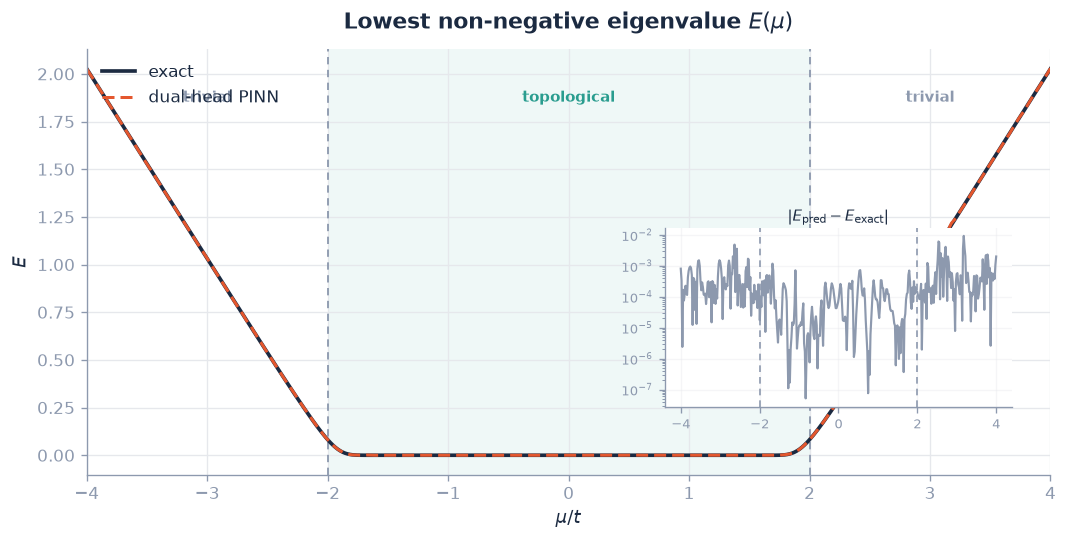

In [15]:
trained_model.eval()

mu_sweep = np.linspace(-4.0, 4.0, 400)
with torch.no_grad():
    mu_tensor = torch.tensor(
        mu_sweep[:, None], dtype=torch.float32, device=accelerator.device
    )
    e_pred_t, psi_pred_t = trained_model(mu_tensor)
e_pred = e_pred_t.cpu().numpy().ravel()
psi_pred = psi_pred_t.cpu().numpy()

e_exact = np.array(
    [np.linalg.eigvalsh(hamiltonian.build(float(m)))[N] for m in mu_sweep]
)
abs_err = np.abs(e_pred - e_exact)
topo = np.abs(mu_sweep) < 2 * t

fig, ax = plt.subplots(figsize=(9, 4.6))
_mark_topological(ax, t, 4.0)
ax.plot(mu_sweep, e_exact, color=INK, lw=2.2, label="exact")
ax.plot(mu_sweep, e_pred, color=CORAL, lw=1.8, ls=(0, (4, 2)), label="dual-head PINN")
ax.fill_between(mu_sweep, e_exact, e_pred, color=CORAL, alpha=0.12, lw=0)
ax.set_title(r"Lowest non-negative eigenvalue $E(\mu)$")
ax.set_xlabel(r"$\mu / t$")
ax.set_ylabel(r"$E$")
_annotate_phases(ax, t, y=ax.get_ylim()[1] * 0.88)
ax.legend(loc="upper left")

inset = ax.inset_axes([0.60, 0.16, 0.36, 0.42])
inset.plot(mu_sweep, abs_err, color=SLATE, lw=1.3)
for x in (-2 * t, 2 * t):
    inset.axvline(x, color=SLATE, ls=(0, (4, 3)), lw=1.0)
inset.set_yscale("log")
inset.set_title(r"$|E_{\rm pred} - E_{\rm exact}|$", fontsize=9, pad=4)
inset.tick_params(labelsize=8)
inset.grid(True, alpha=0.4)

fig.tight_layout()
fig.savefig(session.path() / "energy_sweep.png", bbox_inches="tight")

session.info(f"E(mu) MAE over [-4t, 4t]:       {abs_err.mean():.4e}")
session.info(f"E MAE, topological (|mu| < 2t): {abs_err[topo].mean():.4e}")
session.info(f"E MAE, trivial     (|mu| > 2t): {abs_err[~topo].mean():.4e}")

### C. Eigenvector fidelity and edge localisation

The left panel of Fig. 4 reports the norm of the projection of
$\psi_{\mathrm{pred}}$ onto the span of the two exact eigenvectors of
smallest $|E|$, $\lVert P\,\psi_{\mathrm{pred}} \rVert$, which equals unity
whenever the prediction lies within that subspace -- the well-defined
accuracy measure where the $\pm\lambda_1$ pair is degenerate (Sec. II B).
The right panel shows the combined particle and hole weight on the two
outermost sites at each end, close to unity for a Majorana edge mode and
small once the state delocalises. These are the final-model counterparts of
Fig. 2, resolved in $\mu$ rather than in epoch.

2026-08-27 22:26:56 | INFO | dual-head-semi-supervised | mean subspace fidelity: 0.9992  (min 0.8149)
2026-08-27 22:26:56 | INFO | dual-head-semi-supervised | edge-weight MAE: 1.1349e-03


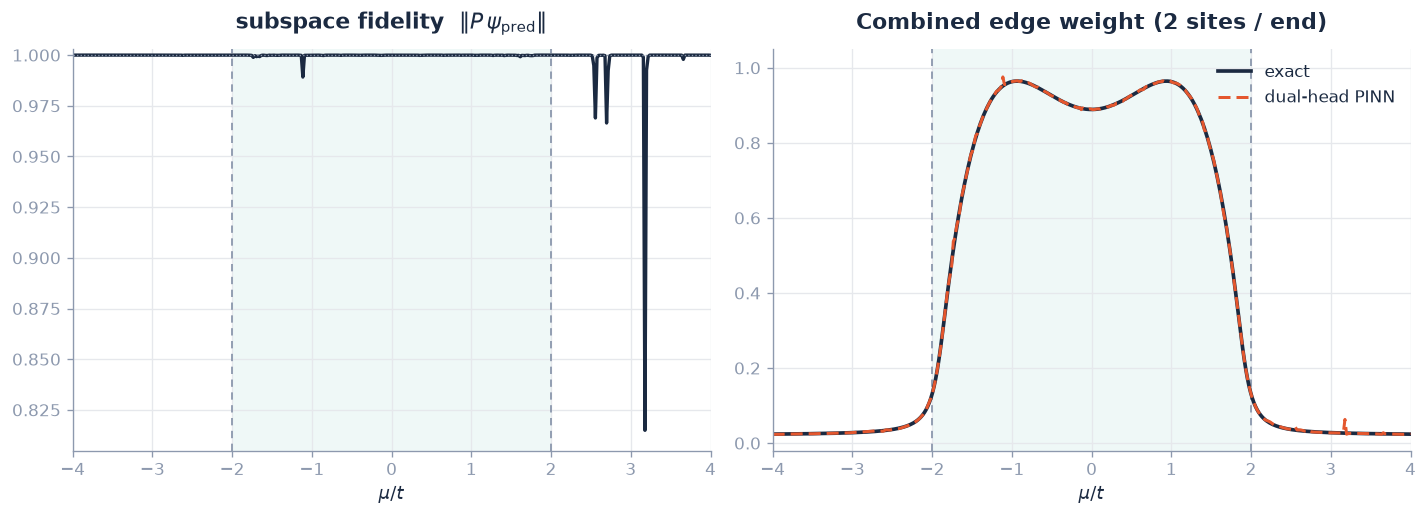

In [16]:
n_edge = 2
edge_idx = np.r_[0:n_edge, N - n_edge : N]

subspace_fidelity = np.empty_like(mu_sweep)
edge_exact = np.empty_like(mu_sweep)
for i, m in enumerate(mu_sweep):
    w, V = np.linalg.eigh(hamiltonian.build(float(m)))
    near_zero = V[:, np.argsort(np.abs(w))[:2]]  # the +/- lambda_min pair
    subspace_fidelity[i] = np.linalg.norm(near_zero.T @ psi_pred[i])
    psi_e = V[:, N]
    edge_exact[i] = (psi_e[:N][edge_idx] ** 2).sum() + (psi_e[N:][edge_idx] ** 2).sum()

prob_pred = psi_pred**2
edge_pred = prob_pred[:, :N][:, edge_idx].sum(1) + prob_pred[:, N:][:, edge_idx].sum(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

_mark_topological(axes[0], t, 4.0)
axes[0].plot(mu_sweep, subspace_fidelity, color=INK, lw=2.0)
axes[0].set_ylim(min(0.95, subspace_fidelity.min() - 0.01), 1.003)
axes[0].axhline(1.0, color=SLATE, lw=0.8, ls=":")
axes[0].set_title(r"subspace fidelity  $\|P\,\psi_{\rm pred}\|$")
axes[0].set_xlabel(r"$\mu / t$")

_mark_topological(axes[1], t, 4.0)
axes[1].plot(mu_sweep, edge_exact, color=INK, lw=2.2, label="exact")
axes[1].plot(
    mu_sweep, edge_pred, color=CORAL, lw=1.8, ls=(0, (4, 2)), label="dual-head PINN"
)
axes[1].set_title("Combined edge weight (2 sites / end)")
axes[1].set_xlabel(r"$\mu / t$")
axes[1].set_ylim(-0.02, 1.05)
axes[1].legend(loc="upper right")

fig.tight_layout()
fig.savefig(session.path() / "eigenvector_agreement.png", bbox_inches="tight")

session.info(
    f"mean subspace fidelity: {subspace_fidelity.mean():.4f}  "
    f"(min {subspace_fidelity.min():.4f})"
)
session.info(f"edge-weight MAE: {np.abs(edge_pred - edge_exact).mean():.4e}")

### D. Probability densities

Figure 5 shows the particle- and hole-sector probability densities
$|\psi_n|^2$ against site index at five values of $\mu$: two deep in the
trivial phase ($\mu = \pm 3.4\,t$), two inside the topological phase
($\mu = \pm 1.0\,t$), and the topological centre ($\mu = 0$). The
topological points should localise at both ends of the chain; the trivial
points should show an extended bulk profile. Because $\psi_{\mathrm{pred}}$
is supervised against the sign- and particle/hole-fixed labels, the split
between the two sectors is a meaningful comparison across the whole domain.

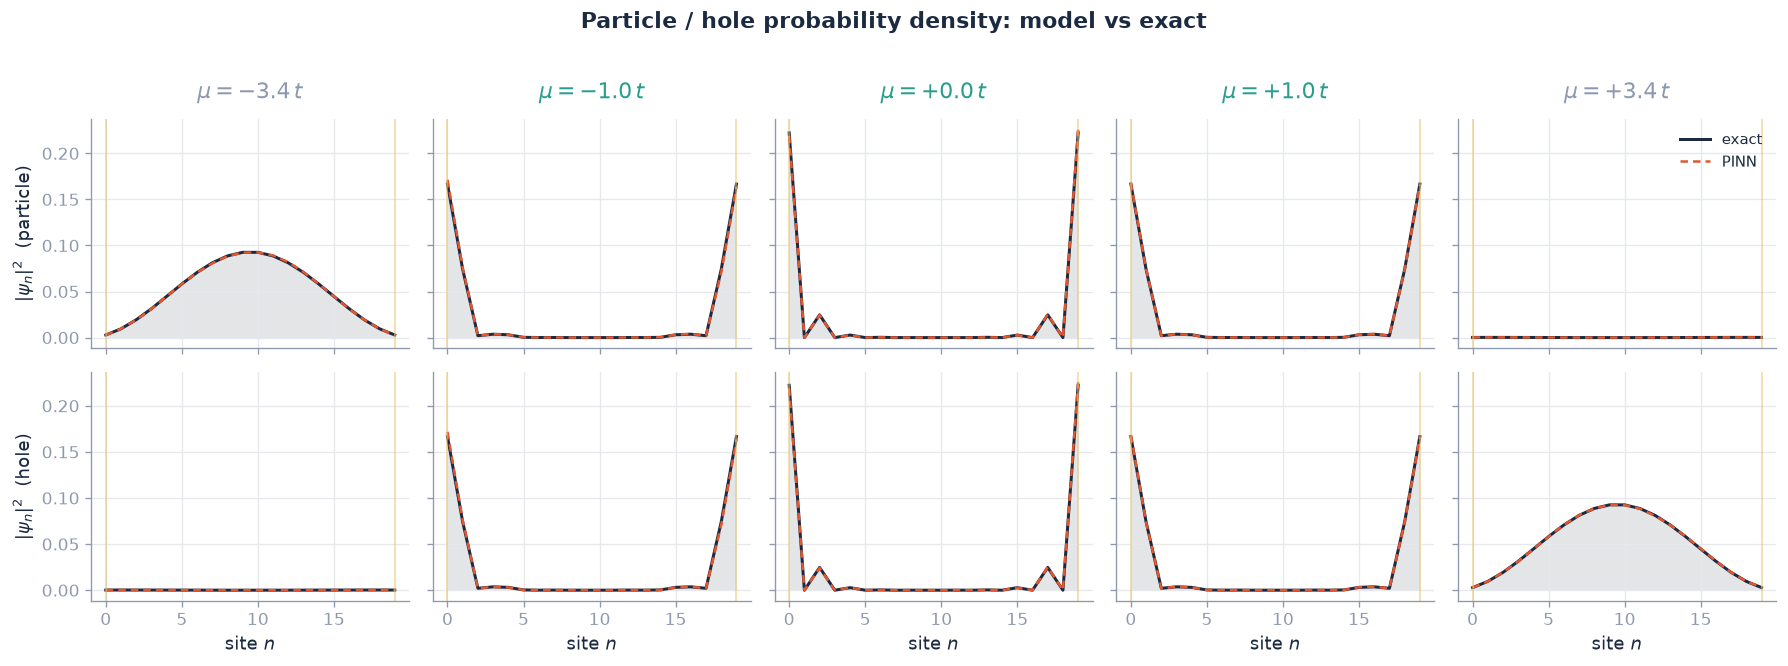

In [17]:
probe_mus = [-3.4, -1.0, 0.0, 1.0, 3.4]
wf = sweep_wavefunctions(
    trained_model, hamiltonian, probe_mus, device=accelerator.device
)

fig, axes = plt.subplots(
    2, len(probe_mus), figsize=(3.0 * len(probe_mus), 5.4), sharex=True, sharey="row"
)
sites = wf.sites

for col, mu in enumerate(probe_mus):
    topo = abs(mu) < 2 * t
    tag_color = TEAL if topo else SLATE
    for row, (exact, pred, label) in enumerate(
        (
            (wf.particle_exact[col], wf.particle_pred[col], "particle"),
            (wf.hole_exact[col], wf.hole_pred[col], "hole"),
        )
    ):
        ax = axes[row, col]
        ax.fill_between(sites, exact, color=INK, alpha=0.12, lw=0)
        ax.plot(sites, exact, color=INK, lw=1.8, label="exact")
        ax.plot(sites, pred, color=CORAL, lw=1.5, ls=(0, (3, 2)), label="PINN")
        for edge in (0, N - 1):
            ax.axvline(edge, color=GOLD, lw=1.0, alpha=0.6)
        if row == 0:
            ax.set_title(rf"$\mu = {mu:+.1f}\,t$", color=tag_color)
        if col == 0:
            ax.set_ylabel(rf"$|\psi_n|^2$  ({label})")
        if row == 1:
            ax.set_xlabel("site $n$")

axes[0, -1].legend(loc="upper right", fontsize=9)
fig.suptitle(
    "Particle / hole probability density: model vs exact",
    y=1.02,
    fontsize=13,
    weight="600",
)
fig.tight_layout()
fig.savefig(session.path() / "wavefunctions.png", bbox_inches="tight")

## VIII. Summary

The dual-head model keeps a small exactly-diagonalised anchor set and
enforces $\lVert \psi \rVert = 1$ and $E \ge 0$ within the architecture,
leaving a four-term loss -- two data terms on the labelled rows, two physics
residuals over the full batch -- with a single physics-weight anneal. The
particle--hole residual is numerically equal to the Schr\"odinger residual
(Sec. II A) and carries no independent information.

Training is in two stages over the full domain $-4t < \mu < 4t$: AdamW under
a cosine decay while $w_{\mathrm{phys}}$ ramps in, then L-BFGS under a
strong-Wolfe line search on frozen single-batch labelled and label-free
pools. `run_two_phase` continues the epoch count into the second stage, so
the anneal does not restart. `BdGEvaluationProbe` records the energy,
edge-weight, and subspace-infidelity errors on the same $\mu$ grid used by
the chiral and forthcoming Nambu notebooks, so the models are directly
comparable; Figs. 3--5 quantify the final-model agreement with exact
diagonalisation.

The residual limitation, unchanged from the earlier version of this
notebook, is the hole-sector eigenvector fit in the trivial phase near the
transition and at the extreme edge sites. Whether the planned depth /
omega / optimiser ablation resolves it is left open.